In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('weather.csv')

In [25]:
df.head()

,days,weather,temperature,humidity,wind,play football
0,d1,sunny,mild,high,weak,no
1,d2,sunny,mild,high,weak,yes
2,d3,cloudy,hot,high,strong,no
3,d4,rain,mild,high,weak,no
4,d5,rain,mild,normal,weak,yes


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

le_x = LabelEncoder()
le_y = LabelEncoder()

x_weather = df[['weather']].copy()
y_weather = df['play football']

x_weather['weather'] = le_x.fit_transform(x_weather['weather'])
y_weather = le_y.fit_transform(y_weather)

weather_IG = DecisionTreeClassifier(criterion='entropy')
weather_IG.fit(x_weather, y_weather)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

[Text(0.6, 0.8333333333333334, 'x[0] <= 1.5\nentropy = 0.985\nsamples = 14\nvalue = [6, 8]'),
 Text(0.4, 0.5, 'x[0] <= 0.5\nentropy = 0.918\nsamples = 9\nvalue = [3, 6]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'entropy = 1.0\nsamples = 4\nvalue = [2, 2]'),
 Text(0.6, 0.16666666666666666, 'entropy = 0.722\nsamples = 5\nvalue = [1, 4]'),
 Text(0.8, 0.5, 'entropy = 0.971\nsamples = 5\nvalue = [3, 2]'),
 Text(0.7, 0.6666666666666667, '  False')]

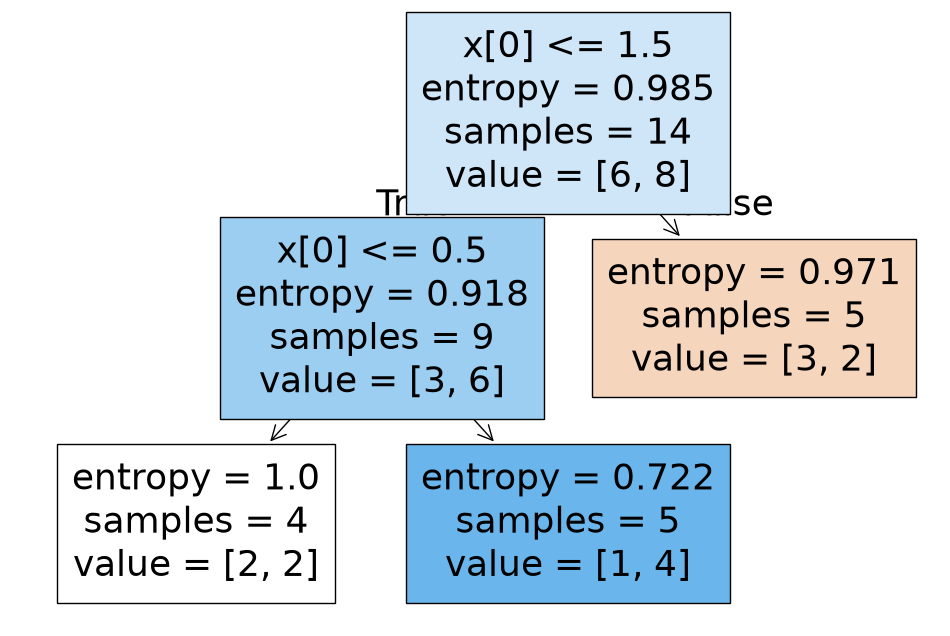

In [27]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(weather_IG,filled=True)

In [41]:
from sklearn.model_selection import train_test_split
le = LabelEncoder()
df_encoded =  df.apply(le.fit_transform)
x= df_encoded[['weather', 'temperature','humidity', 'wind']]
y = df_encoded['play football']



x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.33,random_state=42)
x_train


,weather,temperature,humidity,wind
8,2,0,1,0
2,0,1,0,0
1,2,2,0,1
13,1,2,0,0
4,1,2,1,1
7,2,2,1,1
10,2,0,0,1
3,1,2,0,1
6,0,0,0,1


In [40]:
print(type(x))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


[Text(0.5, 0.9, 'x[1] <= 1.5\nentropy = 0.991\nsamples = 9\nvalue = [4, 5]'),
 Text(0.2, 0.7, 'x[3] <= 0.5\nentropy = 0.811\nsamples = 4\nvalue = [3, 1]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.1, 0.5, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.3, 0.5, 'x[0] <= 1.0\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2, 0.3, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.3, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.7, 'x[2] <= 0.5\nentropy = 0.722\nsamples = 5\nvalue = [1, 4]'),
 Text(0.65, 0.8, '  False'),
 Text(0.7, 0.5, 'x[0] <= 1.5\nentropy = 0.918\nsamples = 3\nvalue = [1, 2]'),
 Text(0.6, 0.3, 'x[3] <= 0.5\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]'),
 Text(0.5, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.7, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.3, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.9, 0.5, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]')]

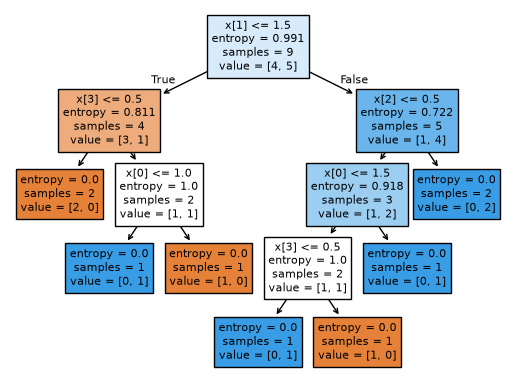

In [45]:

clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(x_train,y_train)
tree.plot_tree(clf,filled = True)